# Reading provenance directly
The processed RO-Crates contain a new directory with provenance data
We can extract provenance data directly without reading Galaxy entities:
```
exp_crate/
|-- datasets/
|   |-- ds_001.xxx
|   `-- ...
|-- provenance/
|   |-- galaxy_run_prov.jsonld
|   |-- galaxy_run_prov.ttl
|   `-- ...
|-- workflow/
|--ro-crate-metadata.json
...        

In [1]:
# using rocrate
from rocrate.rocrate import ROCrate
from pathlib import Path

# defined functions to get data from RO-Crate
from read_provenance import *

file_name = "FeS2-Analysis.rocrate.prov.zip"

file_path = Path("./result_roc", file_name)

crate = ROCrate(file_path)
data_entities = []
for e in crate.get_entities():
    if "provenance/data" in e.id:
        print(e.id, e.type)
        data_entities.append(e.id)
        

C:\Users\scman1\AppData\Roaming\Python\Python39\site-packages\rocrate\vocabs.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


provenance/dataset_df0bac1ee137448a.jsonld File
provenance/dataset_df02c7af9dfe5b62.jsonld File
provenance/dataset_d49ffa4044c67d15.jsonld File
provenance/dataset_6c2ea4582a260280.jsonld File
provenance/dataset_409c0d24534294d8.jsonld File
provenance/dataset_a38f4b5b93cd4e1a.jsonld File
provenance/dataset_a011be860e2a8b79.jsonld File
provenance/dataset_547228271cdb66e2.jsonld File
provenance/dataset_75738551921d866c.jsonld File
provenance/dataset_c3e4da2bb600d6e3.jsonld File
provenance/dataset_a9305118c6acc078.jsonld File
provenance/dataset_fb5bc774c9b03fce.jsonld File


In [2]:
f = get_file_from_rocratezip(file_path, data_entities[0])
details = json.load(f)

In [3]:
print(json.dumps(details, indent=4))

{
    "@context": {
        "cdif4xas": "https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#",
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_df0bac1ee137448a.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "cdif4xas:beamline": "GSECARS 13BM, vert slits = 2mm (at 45m)",
    "cdif4xas:e0": "7117.0",
    "cdif4xas:edge": "K",
    "cdif4xas:element": "Fe",
    "cdif4xas:sample_formula": "FeS2",
    "cdif4xas

In [4]:
def get_roc_provenance(roc_file):
    roc_graph = Graph()
    f = get_file_from_rocratezip(roc_file, "provenance/galaxy_run_prov.jsonld")
    json_roc = json.load(f)
    roc_graph.parse(
        data=json.dumps(json_roc),
        format="json-ld",publicID="/"
    )
    roc_graph = fix_graph_root(roc_graph)
    return roc_graph
    
def fix_graph_root(a_graph):
    new_graph = Graph()
    
    for s, p, o in a_graph:    
        if isinstance(s, URIRef) and str(s).startswith("file:///"):
            s = URIRef(str(s).replace("file://", "", 1))
        if isinstance(o, URIRef) and str(o).startswith("file:///"):
            o = URIRef(str(o).replace("file://", "", 1))
        new_graph.add((s, p, o))
    return new_graph

an_roc_graph = get_roc_provenance(file_path)

In [5]:
#get datasets provenance from the roc graph
datasets_provenance = get_datasets_prov(an_roc_graph)
display(HTML(datasets_provenance.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,fes2_rt01_mar02.xmu,None
1,/step/1,fetch data from history,DATA_FETCH,1564889.cif,None
2,/step/2,process and normalise XAS,larch_athena,FeS2_athena,fes2_rt01_mar02.xmu
3,/step/2,process and normalise XAS,larch_athena,FeS2_plot,fes2_rt01_mar02.xmu
4,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF input of 1564889.cif,1564889.cif
5,/step/3,calculate FEFF paths from crystal,larch_feff,FEFF paths of 1564889.cif,1564889.cif
6,/step/3,calculate FEFF paths from crystal,larch_feff,CSV summary of 1564889.cif,1564889.cif
7,/step/4,select FEFF paths,larch_select_paths,fes2_sp,"FEFF paths of 1564889.cif, CSV summary of 1564889.cif"
8,/step/4,select FEFF paths,larch_select_paths,fes2_gds,"FEFF paths of 1564889.cif, CSV summary of 1564889.cif"
9,/step/5,FEFF fit of XAS,larch_artemis,rmr_FeS2,"FEFF paths of 1564889.cif, fes2_gds, FeS2_athena, fes2_sp"


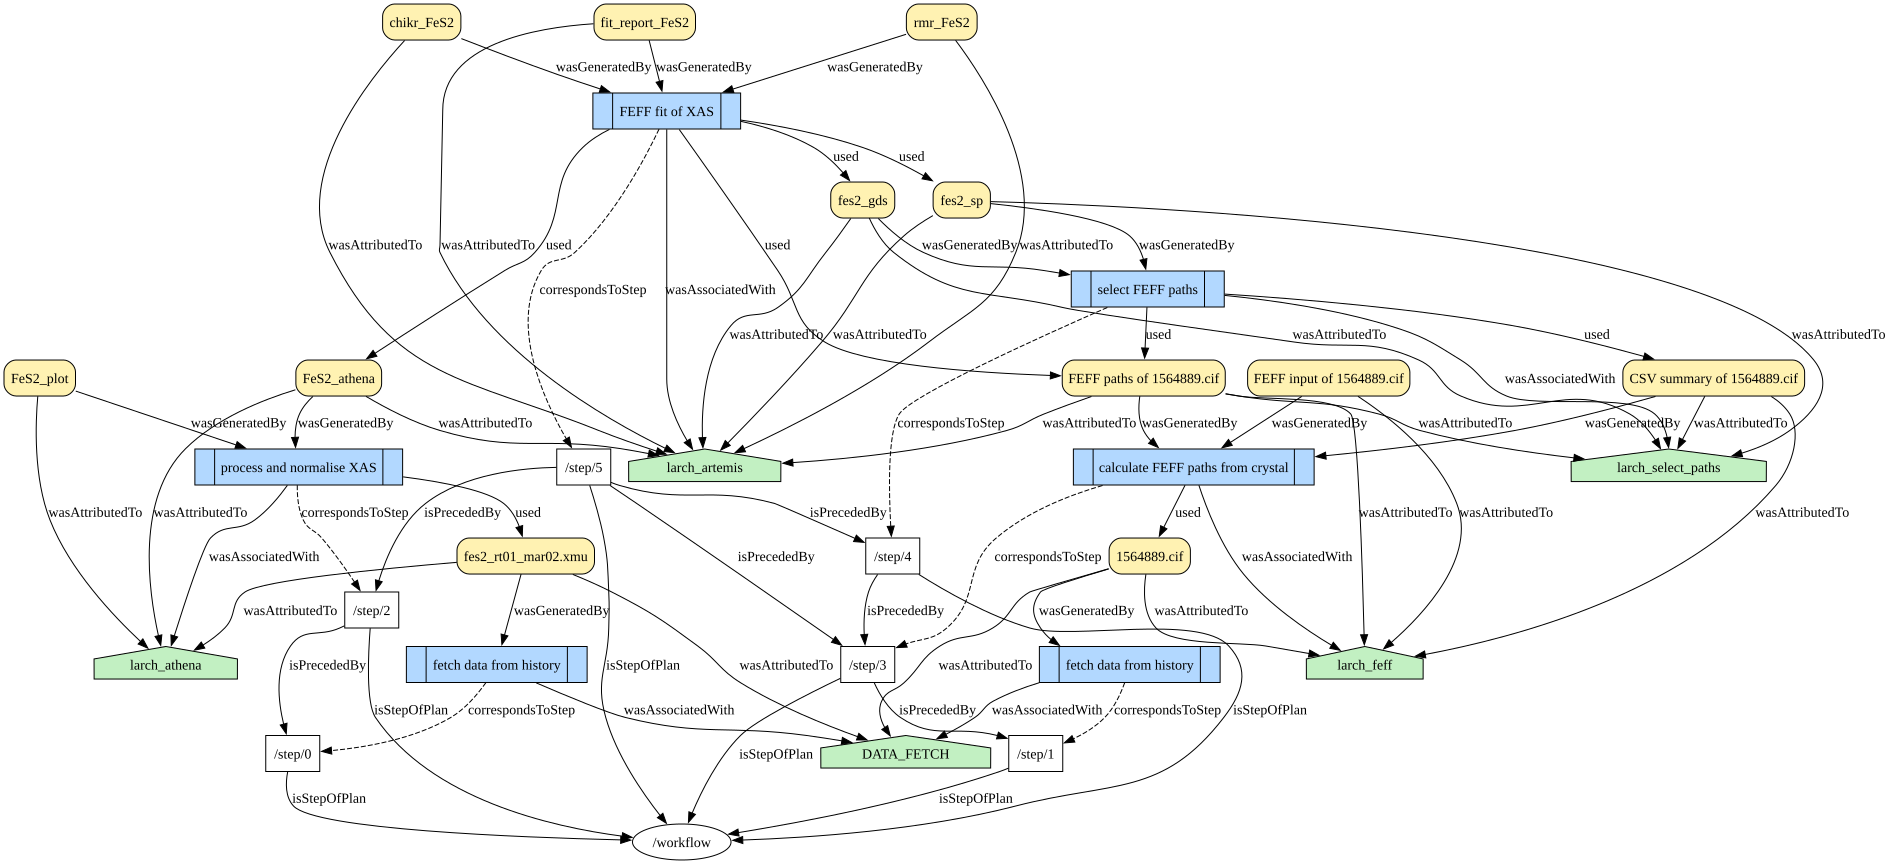

In [6]:
#plan_dot = draw_prov_only(an_roc_graph)
#display(plan_dot)

#plan_dot = draw_pplan_only(an_roc_graph)
#display(plan_dot)

fullprov_dot = draw_prov_full(an_roc_graph)
display(fullprov_dot)

In [7]:
ds_jsons = show_datasets(an_roc_graph, file_path, output_path = "",  show_only = True)

,Property,Value
0,schema:id,datasets/fes2_rt01_mar02.xmu_df0bac1ee137448a.txt
1,prov:wasGeneratedBy,fetch data from history
2,dcterms:format,text/plain
3,skos:prefLabel,fes2_rt01_mar02.xmu
4,rdf:type,prov:Entity
5,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
6,rdf:type,schema:MediaObject
7,prov:wasAttributedTo,DATA_FETCH
8,prov:wasAttributedTo,larch_athena
9,dcterms:description,uploaded txt file


,Property,Value
0,prov:wasAttributedTo,DATA_FETCH
1,prov:wasAttributedTo,larch_feff
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
3,rdf:type,prov:Entity
4,rdf:type,schema:MediaObject
5,dcterms:format,chemical/x-cif
6,skos:prefLabel,1564889.cif
7,dcterms:description,"Metadata is limited as the Atomic Simulation Environment (ASE) is not installed.You can still use this dataset in tools and workflows.For full metadata, ask your admin to install the 'ase' Python package."
8,schema:id,datasets/1564889.cif_df02c7af9dfe5b62.cif
9,prov:wasGeneratedBy,fetch data from history


,Property,Value
0,prov:wasAttributedTo,larch_artemis
1,prov:wasAttributedTo,larch_athena
2,rdf:type,prov:Entity
3,rdf:type,schema:MediaObject
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,dcterms:description,atsym: Febkg_e0: 7117.0edge: Knpts: 352xmax: 7963.5xmin: 6911.8
6,prov:wasGeneratedBy,process and normalise XAS
7,dcterms:format,application/vnd.demeter.athena
8,skos:prefLabel,FeS2_athena
9,schema:id,datasets/FeS2_athena_d49ffa4044c67d15.prj


,Property,Value
0,rdf:type,schema:MediaObject
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
2,rdf:type,prov:Entity
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,schema:id,datasets/FeS2_plot_6c2ea4582a260280.png
5,dcterms:description,"Attempting to read from /mnt/nfs/data/f/6/4/dataset_f640df2f-ce68-4309-bc83-2e052fb749f1.datRead columns: ['energy', 'xmu', 'i0']'energy' present in column headersRenaming columns to: ['energy', 'mu', 'i0']Cannot load group.athena_params.bkg from gro"
6,skos:prefLabel,FeS2_plot
7,prov:wasGeneratedBy,process and normalise XAS
8,dcterms:format,image/png
9,prov:wasAttributedTo,larch_athena


,Property,Value
0,rdf:type,schema:MediaObject
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
2,rdf:type,prov:Entity
3,schema:id,datasets/FEFF_input_of_1564889.cif_409c0d24534294d8.inp
4,prov:wasGeneratedBy,calculate FEFF paths from crystal
5,skos:prefLabel,FEFF input of 1564889.cif
6,prov:wasAttributedTo,larch_feff
7,dcterms:description,Formula: FeS2SpaceGroup: Pnnm# sites: 6
8,dcterms:format,chemical/x-feff-input
9,dcterms:subject,<http://purl.org/pan-science/PaNET/PaNET01082>


...

,Property,Value
0,prov:wasGeneratedBy,select FEFF paths
1,prov:wasAttributedTo,larch_select_paths
2,prov:wasAttributedTo,larch_artemis
3,rdf:type,prov:Entity
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,rdf:type,schema:MediaObject
6,schema:id,datasets/fes2_sp_75738551921d866c.sp
7,dcterms:format,text/csv
8,dcterms:description,
9,skos:prefLabel,fes2_sp


,Property,Value
0,rdf:type,schema:MediaObject
1,rdf:type,prov:Entity
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
3,prov:wasGeneratedBy,select FEFF paths
4,prov:wasAttributedTo,larch_select_paths
5,prov:wasAttributedTo,larch_artemis
6,dcterms:format,text/csv
7,dcterms:description,
8,schema:id,datasets/fes2_gds_547228271cdb66e2.gds
9,skos:prefLabel,fes2_gds


,Property,Value
0,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
1,rdf:type,prov:Entity
2,rdf:type,schema:MediaObject
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,prov:wasGeneratedBy,FEFF fit of XAS
6,skos:prefLabel,rmr_FeS2
7,dcterms:format,image/png
8,schema:id,datasets/rmr_FeS2_fb5bc774c9b03fce.png
9,prov:wasAttributedTo,larch_artemis


,Property,Value
0,skos:prefLabel,fit_report_FeS2
1,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
2,prov:wasGeneratedBy,FEFF fit of XAS
3,schema:id,datasets/fit_report_FeS2_a9305118c6acc078.feffit
4,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
5,rdf:type,prov:Entity
6,rdf:type,schema:MediaObject
7,dcterms:format,text/plain
8,prov:wasAttributedTo,larch_artemis
9,dcterms:subject,<http://purl.org/pan-science/PaNET/PaNET01197>


,Property,Value
0,rdf:type,schema:MediaObject
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct>
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
3,rdf:type,prov:Entity
4,dcterms:format,image/png
5,dcterms:description,Archive: /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat creating: feff/ inflating: feff/feff.inp inflating: feff/feffrun_feff6l.log inflating: feff/feff.run inflating: feff/misc.dat inflating: feff/phase.bin inflatin
6,prov:wasGeneratedBy,FEFF fit of XAS
7,schema:id,datasets/chikr_FeS2_c3e4da2bb600d6e3.png
8,skos:prefLabel,chikr_FeS2
9,prov:wasAttributedTo,larch_artemis


In [8]:
from collections import Counter
from rdflib import RDF, Namespace

PROV = Namespace("http://www.w3.org/ns/prov#")
entities = set(an_roc_graph.subjects(RDF.type, PROV.Entity))

types = Counter()
formats = Counter()
subjects = Counter()
for e in entities:
    # entity types
    for t in an_roc_graph.objects(e, RDF.type):
        if t != PROV.Entity:
            types[str(t).split("/")[-1]] += 1

    # file formats
    for f in an_roc_graph.objects(e, DCTERMS.format):
        formats[str(f)] += 1

    # file subjects
    
    #for p, o in an_roc_graph.predicate_objects(e):
    #    print(p, o)
    #    if str(p).startswith(str(CDIF4XAS)):
    #        print(p, o)
        #print("*"*80)
        #print(e)
        #print(d)
        #subjects[str(s)] += 1

print("Total datasets:", len(entities))

print("\nTypes")
for k, v in types.most_common():
    print(f"{k}: {v}")

print("\nFormats")
for k, v in formats.most_common():
    print(f"{k}: {v}")
    
print("\nSubjects")
for k, v in subjects.most_common():
    print(f"{k}: {v}")

Total datasets: 12

Types
MediaObject: 12
CDIF-PROV#Dataset: 12
CDIF-PROV#DataProduct: 3

Formats
image/png: 3
text/csv: 3
text/plain: 2
chemical/x-feff-input: 1
chemical/x-cif: 1
application/zip: 1
application/vnd.demeter.athena: 1

Subjects


In [9]:
# now read it from json-lds of datasets
# assing processing levels using sweet
inv = get_roc_json_part(file_path, data_entities[3])
print(json.dumps(inv, indent=4))

{
    "@context": {
        "cdif4xas": "https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#",
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_6c2ea4582a260280.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "cdifprov:DataProduct",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "cdif4xas:beamline": "GSECARS 13BM, vert slits = 2mm (at 45m)",
    "cdif4xas:edge": "K",
    "cdif4xas:sample_formula": "FeS2",
    "cdif4xas:sample_name": "FeS2 powder

In [10]:
small_graph = Graph()
#small_graph = get_panet_entities()
small_graph.parse("resources/panent_fragment.ttl")
small_graph.parse("resources/sweet-pl.ttl") 
for an_ent in data_entities:
    inv = get_roc_json_part(file_path, an_ent)
    small_graph.parse(
            data=json.dumps(inv),
            format="json-ld",publicID="/"
        )
    break
small_graph = fix_graph_root(small_graph)

In [11]:
nx_graph = rdflib_to_networkx_graph(small_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 56 nodes and 46 edges loaded successfully
nx.html


In [12]:
def get_panet_entities():
    full_graph = Graph()
    full_graph.parse("resources/panet.ttl")
    reduced_lookup = Graph()
    for an_id in PANET_IDS.values():
        for a_triple in full_graph.triples((an_id, None, None)):
            reduced_lookup.add(a_triple)
    return reduced_lookup

panet_graph = get_panet_entities()
# panet_graph
# save reduced panet ontology (only used clasess)
# panet_graph.serialize(destination="resources/panent_fragment.ttl", format="ttl")

In [13]:
# This is how individual dataset JSON files are generated
for ds_entity in entities:
    ds_properties = get_dataset_properties(ds_entity, an_roc_graph)
    ds_properties = add_panet_class(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_processing_level(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_ancestor(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_cdif_metadata(ds_entity, ds_properties, an_roc_graph, file_path)
    print(ds_properties)
    break

[[rdflib.term.URIRef('http://purl.org/dc/terms/description'), rdflib.term.Literal('\nArchive:  /mnt/nfs/data/d/4/a/dataset_d4a101e2-a73e-4eac-8f30-75f043982880.dat\n   creating: feff/\n  inflating: feff/feff.inp\n  inflating: feff/feffrun_feff6l.log\n  inflating: feff/feff.run\n  inflating: feff/misc.dat\n  inflating: feff/phase.bin\n  inflatin')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://www.w3.org/ns/prov#Entity')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://schema.org/MediaObject')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#DataProduct')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset')], [rdflib.term.URIRef('http://www.w3.org/ns/prov#wasGen

In [14]:
for a_key in ["element", "e0", "edge", "sample_name", "sample_formula"]:
    pred = CDIF4XAS[a_key]
    print (pred)

https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#element
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#e0
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#edge
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_name
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_formula


In [15]:
def get_ancestors(graph, entity):
    seen = set()
    stack = [entity]
    while stack:
        current = stack.pop()
        for activity in graph.objects(current, PROV.wasGeneratedBy):
            for parent in graph.objects(activity, PROV.used):
                if parent not in seen:
                    seen.add(parent)
                    stack.append(parent)
    return seen

def get_descendants(graph, entity):
    seen = set()
    stack = [entity]
    while stack:
        current = stack.pop()
        for activity in graph.subjects(PROV.used, current):
            for child in graph.subjects(
                PROV.wasGeneratedBy,
                activity
            ):
                if child not in seen:
                    seen.add(child)
                    stack.append(child)
    return seen

def get_full_ancestry(a_graph, an_entity):
    all_ancestors = get_ancestors(a_graph, an_entity)
    all_descendants = get_descendants(a_graph, an_entity)
    return {"entity": an_entity, "ancestors": all_ancestors, "descendants": all_descendants}

def get_values_custom_xmu_textfile(file_path, filename):
    f = get_file_from_rocratezip(file_path, filename)
    return_dict = {}
    for line in f:
        text = line.decode('utf-8')
        if text[0] == "#":
            if "#%name:" in text: 
                #print(f"name: {text[7:].strip()}")
                return_dict["sample_name"] = text[7:].strip()
            elif "#%atom:" in text: 
                #print(f"Sample: {text[7:].strip()}")
                return_dict["sample_formula"] = text[7:].strip()
            elif "#%edge:" in str(line): 
                #print(f"Edge: {text[7:].strip()}")
                return_dict["edge"] = text[7:].strip()
            elif "#%temp:" in str(line): 
                #print(f"Temperature: {text[7:].strip()}")
                return_dict["temperature"] = text[7:].strip()
            elif "#%beam:" in str(line): 
                #print(f"Beamline: {text[7:].strip()}")
                return_dict["beamline"] = text[7:].strip()
        else:
          break
    return return_dict

def get_entity_type(graph_thing, an_entity):
    for a_type in graph_thing.objects(an_entity, DCTERMS.format):
        return a_type

def get_entity_path(graph_thing, an_entity):
    for a_path in graph_thing.objects(an_entity, SCHEMA.id):
        return a_path

def get_entity_description(graph_thing, an_entity):
    for a_desc in graph_thing.objects(an_entity, DCTERMS.description):
        return a_desc

def get_entity_metadata(roc_path, graph_thing, an_entity):
    a_type = str(get_entity_type(graph_thing, an_entity))
    
    vals_entity = {}
    
    # text types
    if a_type in ["text/plain", "chemical/x-cif", 
                  "text/csv", "application/xdi"]:
        filename = str(get_entity_path(graph_thing, an_entity))
        #print (get_a_label(graph_thing, an_entity)[-4:])
        if get_a_label(graph_thing, an_entity)[-4:] == ".xmu":
        #    print("getting xmu metadata")
            vals_entity = get_values_custom_xmu_textfile(roc_path, filename)
        # need other methods for xdi and dat files from different beamlines
    elif a_type in ["application/vnd.demeter.athena"]:
        # athena project files
        entity_desc = get_entity_description(graph_thing, an_entity)
        vals_entity = get_values_athena_project(entity_desc)
    return vals_entity

def get_values_athena_project(athena_descr):
    athena_split = athena_descr.split("\n")
    return_dict = {}
    for a_line in athena_split:
        [k,v] = a_line.split(": ")
        if k == "atsym":
             k =  "element"
        elif k == 'bkg_e0':
            k = "e0"
        elif k == 'npts':
            k = "points"
        elif k == 'xmax':
            k = 'energy_max'
        elif k == 'xmin':
            k = 'energy_min'
        return_dict[k] = v 
    return return_dict

def add_cdif_metadata(an_entity, ds_properties, roc_graph, a_file_path):
    
    print (get_a_label(roc_graph, an_entity), '->')
    entity_ancestry = get_full_ancestry(roc_graph, an_entity)
    branch_metadata = {}
    branch_metadata[entity_ancestry["entity"]] = get_entity_metadata(a_file_path, roc_graph, entity_ancestry["entity"])
    
    for an_ancestor in entity_ancestry["ancestors"]:
        branch_metadata[an_ancestor] = get_entity_metadata(a_file_path, roc_graph, an_ancestor)
    
    for a_descendant in entity_ancestry["descendants"]:
        branch_metadata[a_descendant] = get_entity_metadata(a_file_path, roc_graph, a_descendant)
    
    # for the first case is OK to join them all
    
    sinlge_metadata = {}
    
    for an_entity in branch_metadata:
        if branch_metadata[an_entity] != {}:
            sinlge_metadata = sinlge_metadata|branch_metadata[an_entity]
    
    # actual metadata pairs
    branch_prov_metadata = [] 
    for a_key in sinlge_metadata:
            if a_key in ["element", "e0", "edge", "sample_name", 
                         "sample_formula", "beamline"]:
                pred = CDIF4XAS[a_key]
                branch_prov_metadata.append([pred, sinlge_metadata[a_key]])
    
    ds_properties += branch_prov_metadata
    return ds_properties

for an_entity in entities:
    #ds_properties = add_cdif_metadata(an_entity, ds_properties, an_roc_graph, file_path)
    #print (ds_properties)
    #break
    the_entity = an_entity
    print (get_a_label(an_roc_graph, the_entity), '->')
    entity_ancestry = get_full_ancestry(an_roc_graph, the_entity)
    branch_metadata = {}
    branch_metadata[entity_ancestry["entity"]] = get_entity_metadata(file_path, an_roc_graph, entity_ancestry["entity"])
    
    for an_ancestor in entity_ancestry["ancestors"]:
        branch_metadata[an_ancestor] = get_entity_metadata(file_path, an_roc_graph, an_ancestor)
    
    for a_descendant in entity_ancestry["descendants"]:
        branch_metadata[a_descendant] = get_entity_metadata(file_path, an_roc_graph, a_descendant)
    
    # for the first case is OK to join them all
    
    sinlge_metadata = {}
    
    for an_entity in branch_metadata:
        if branch_metadata[an_entity] != {}:
            sinlge_metadata = sinlge_metadata|branch_metadata[an_entity]
    
    # actual metadata pairs
    branch_prov_metadata = [] 
    for a_key in sinlge_metadata:
            if a_key in ["element", "e0", "edge", "sample_name", 
                         "sample_formula", "beamline"]:
                pred = CDIF4XAS[a_key]
                branch_prov_metadata.append([pred, sinlge_metadata[a_key]])
    
    print(branch_prov_metadata)


rmr_FeS2 ->
[[rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_name'), 'FeS2 powder  Room Temperature'], [rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_formula'), 'FeS2'], [rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#edge'), 'K'], [rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#beamline'), 'GSECARS 13BM, vert slits = 2mm (at 45m)'], [rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#element'), 'Fe'], [rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#e0'), '7117.0']]
fit_report_FeS2 ->
[[rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_name'), 'FeS2 powder  Room Temperature'], [rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_formula'), 'FeS2'], [rdflib.term.URIRef('https://worldfair